## 응집형(Agglomerative) 계층적 클러스터링
### 정의
- 주어진 데이터에서 개별 데이터 하나하나를 독립된 클러스터로 가정하고 이들을 특정 알고리즘에 의해
병합하여 상위단계 클러스터를 구성하고, 이렇게 구성된 상위단계 클러스터를 특정 알고리즘에 의해 또
다시 병합하여 최종적으로 데이터 전체를 멤버로 하는 하나의 클러스터로 구성하는 방법이다.
### 계층적 클러스터링 알고리즘
### 단순연결(single linkage,Nearest Neighbor)
- 2개의 클러스터에서 각 클러스터에 속하는 멤버 사이의 거리가 가장 가까운 거리를 모두 계산하고, 이 값들중 가장
작은 값들을 가지는 2개의 클러스터를 병합하여 상위 단계 클러스터를 구성한다.
### 완전연결(complete linkage, Furthest Neighbor)
- 2개의 클러스터에서 각 클러스터에 속하는 멤버사이의 거리가 가장 먼 거리를 모두 계산하고 이 값들중 가장 작은
값을 가지는 2개의 클러스터를 병합하여 상위 단계 클러스터를 구성한다.

           X         Y
점0  6.121702  1.690698
점1  4.360590  7.692625
점2  2.953253  1.491630
점3  0.224783  4.202245
점4  2.386821  3.376562


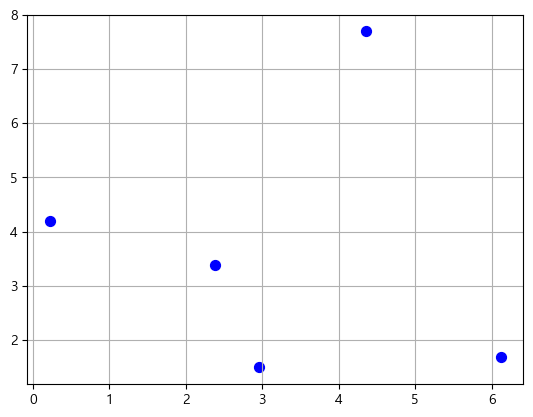

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(111)
var = ['X','Y']
labels = ['점0','점1','점2','점3','점4']
X = np.random.random_sample([5,2])*10
df = pd.DataFrame(X, columns=var, index=labels)
print(df)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.scatter(X[:,0],X[:,1], c='blue', marker='o', s=50)
plt.grid(True)
plt.show()

In [5]:
from scipy.spatial.distance import pdist, squareform
# # pdist() : 주어진 점들 사이의 모든 거리를 계산한다.
distmatrix = pdist(df, metric='euclidean')
distmatrix

array([6.25496953, 3.1746961 , 6.40948658, 4.09773961, 6.35869002,
       5.41180656, 4.74596264, 3.84603471, 1.96820089, 2.31433823])

In [7]:
# squareform() : 대칭 행렬의 전체 및 "압축 된"형식 간을 전환한다.
#                주어진 데이터로 대칭행렬을 만들고 대각선은 0으로 채운다.
row_dist = pd.DataFrame(squareform(distmatrix), columns=labels, index=labels)
row_dist

,점0,점1,점2,점3,점4
점0,0.000000,6.254970,3.174696,6.409487,4.097740
점1,6.254970,0.000000,6.358690,5.411807,4.745963
점2,3.174696,6.358690,0.000000,3.846035,1.968201
점3,6.409487,5.411807,3.846035,0.000000,2.314338
점4,4.097740,4.745963,1.968201,2.314338,0.000000


In [8]:
from scipy.cluster.hierarchy import linkage

row_clusters = linkage(distmatrix, method='complete')
row_clusters

array([[2.        , 4.        , 1.96820089, 2.        ],
       [3.        , 5.        , 3.84603471, 3.        ],
       [0.        , 1.        , 6.25496953, 2.        ],
       [6.        , 7.        , 6.40948658, 5.        ]])

In [9]:
pd.DataFrame(row_clusters, columns=['클러스터ID_1','클러스터ID_2','거리','클러스터 멤버수'],
            index = ['클러스터 %d' % (i+1) for i in range(row_clusters.shape[0])])

,클러스터ID_1,클러스터ID_2,거리,클러스터 멤버수
클러스터 1,2.0,4.0,1.968201,2.0
클러스터 2,3.0,5.0,3.846035,3.0
클러스터 3,0.0,1.0,6.254970,2.0
클러스터 4,6.0,7.0,6.409487,5.0


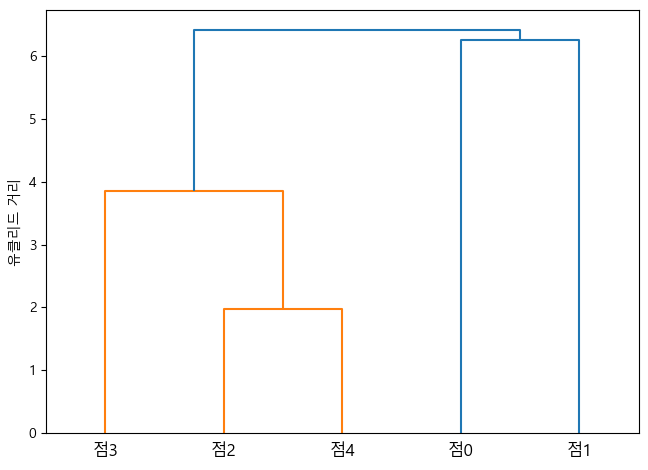

In [11]:
from scipy.cluster.hierarchy import dendrogram

row_dendrogram = dendrogram(row_clusters, labels=labels)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.tight_layout()
plt.ylabel('유클리드 거리')
plt.show()

In [13]:
from scipy.cluster.hierarchy import fcluster

predict = fcluster(row_clusters, 6.4, criterion='distance')
predict

array([2, 2, 1, 1, 1], dtype=int32)

In [12]:
from sklearn.cluster import AgglomerativeClustering

ac = AgglomerativeClustering(n_clusters=2, metric = 'euclidean', linkage='complete')
labels = ac.fit_predict(X)
print('클러스터 분류 결과 :', labels)

클러스터 분류 결과 : [0 0 1 1 1]


In [14]:
import statsmodels.api as sm

iris = sm.datasets.get_rdataset('iris', package='datasets')
iris_df = iris.data
iris_df

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


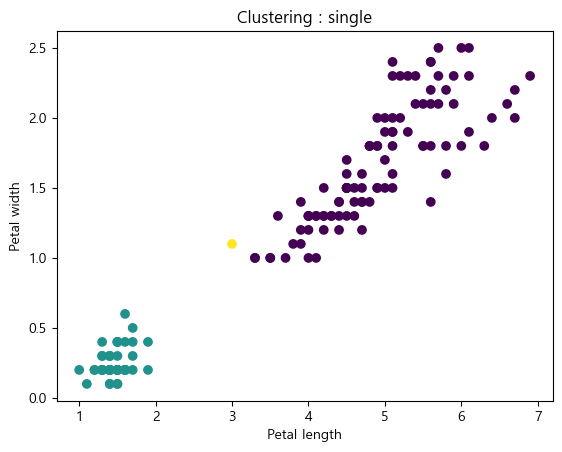

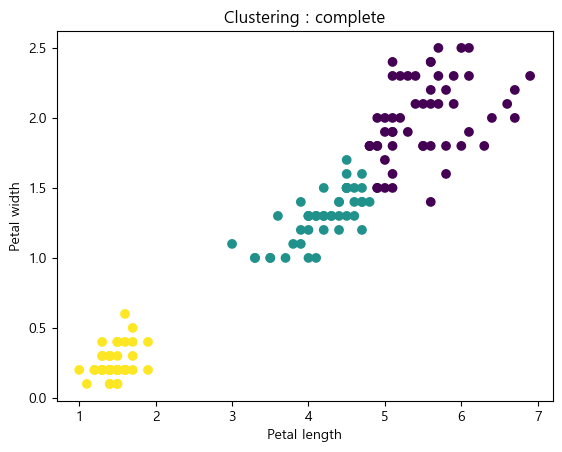

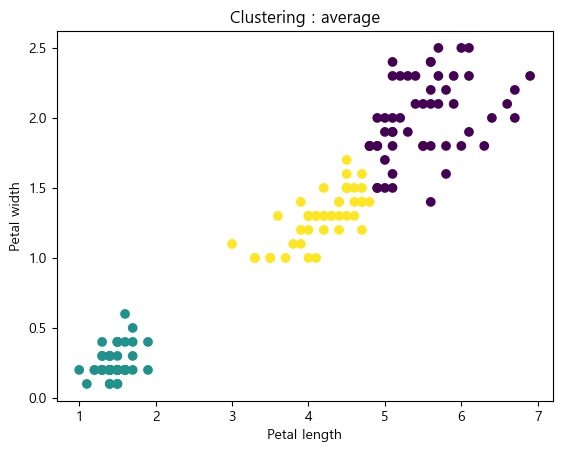

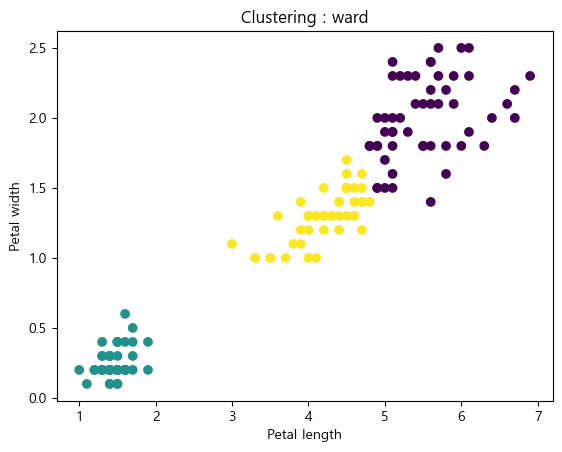

In [17]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

linkage = ['single','complete', 'average', 'ward']
for idx, i in enumerate(linkage):
    plt.figure(idx)
    hier = AgglomerativeClustering(n_clusters=3, metric = 'euclidean', linkage=i)
    hier.fit(iris_df.iloc[:,2:4])
    plt.scatter(iris_df.iloc[:,2], iris_df.iloc[:,3], c= hier.labels_)
    plt.title('Clustering : ' + i)
    plt.xlabel('Petal length')
    plt.ylabel('Petal width')
plt.show()